# 05 – Entalpías de Reacción y Calores de Combustión

Como el $H^\circ(T)$ de `pyglenn` está *estandarizado* (ya incluye la entalpía
de formación de cada especie, cuaderno 04), la entalpía estándar de reacción es
simplemente una suma estequiométrica de entalpías:

$$\Delta H_\mathrm{rxn}(T) = \sum_{\text{productos}} \nu_j\,H^\circ_j(T)
   - \sum_{\text{reactivos}} \nu_i\,H^\circ_i(T).$$

Sin tabla separada de entalpías de formación, sin contabilidad de la ley de
Hess — una llamada por especie. Usamos esto para calcular calores de combustión
(PCI/PCS), su dependencia con la temperatura (ley de Kirchhoff) y para demostrar
la ley de Hess.

> **Nota sobre el estado estándar de gas ideal:** Las propiedades de los
> polinomios NASA representan el **estado estándar de gas ideal** (1 bar). A
> altas presiones o para mezclas con fases condensadas, deben aplicarse
> correcciones de no idealidad (ej.: coeficientes de fugacidad, ecuaciones de
> estado) — los valores brutos de `h_relative` de `pyglenn` son el límite de
> gas ideal.

In [1]:
from pyglenn import ThermochemicalCalculator, R

print("Universal gas constant R =", R, "J/(mol.K)")


Constante universal de los gases R = 8.314462618 J/(mol.K)


In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")


## 1. Una función genérica para entalpía de reacción

Las reacciones se expresan como diccionarios
`{nombre_especie: coeficiente_estequiométrico}`. El auxiliar devuelve
$\Delta H_\mathrm{rxn}$ en J/mol a cualquier temperatura.

In [3]:
def reaction_enthalpy(calc, reactants, products, T=298.15):
    """Entalpía estándar de reacción en J/mol a la temperatura T (Kelvin)."""
    def total(mix):
        h = 0.0
        for name, nu in mix.items():
            h += nu * calc.calculate_properties(calc.get_available_species(name, exact_match=True)[0]["id"], T)["h_relative"]
        return h
    return total(products) - total(reactants)

## 2. Validación contra reacciones conocidas

Cuatro reacciones clásicas de libros de texto a 298,15 K (agua producto en
estado gaseoso). Los valores calculados coinciden con las entalpías de reacción
estándar aceptadas con error de fracción de kJ/mol.

In [4]:
REACTIONS = {
    "CO + 1/2 O2 -> CO2":              ({"CO": 1, "O2": 0.5}, {"CO2": 1}, -283.0),
    "H2 + 1/2 O2 -> H2O(g)":           ({"H2": 1, "O2": 0.5}, {"H2O": 1}, -241.8),
    "CH4 + 2 O2 -> CO2 + 2 H2O(g)":    ({"CH4": 1, "O2": 2}, {"CO2": 1, "H2O": 2}, -802.3),
    "C2H5OH + 3 O2 -> 2 CO2 + 3 H2O":  ({"C2H5OH": 1, "O2": 3}, {"CO2": 2, "H2O": 3}, -1277.5),
}

rows = []
with ThermochemicalCalculator() as calc:
    for label, (reac, prod, ref) in REACTIONS.items():
        dh = reaction_enthalpy(calc, reac, prod) / 1000.0
        rows.append({"reacción": label, "pyglenn [kJ/mol]": dh,
                     "referencia [kJ/mol]": ref, "error": abs(dh - ref)})
print(pd.DataFrame(rows).set_index("reacción").to_string())

                                pyglenn [kJ/mol]  referencia [kJ/mol]  error
reacción                                                                    
CO + 1/2 O2 -> CO2                      -282.973             -283.000  0.027
H2 + 1/2 O2 -> H2O(g)                   -241.825             -241.800  0.025
CH4 + 2 O2 -> CO2 + 2 H2O(g)            -802.557             -802.300  0.257
C2H5OH + 3 O2 -> 2 CO2 + 3 H2O        -1,277.541           -1,277.500  0.041


## 3. Calores de combustión (Poder Calorífico Inferior)

El **poder calorífico inferior** (PCI, o LHV) es el calor liberado por mol de
combustible con el agua producto permaneciendo como **vapor**:
$\text{PCI} = -\Delta H_\mathrm{comb}$. Lo calculamos para una variedad de
combustibles y también lo expresamos por kilogramo, la figura de mérito para
combustibles de transporte.

In [5]:
# combustible -> (moles O2, producto CO2, producto H2O) para combustión completa
FUELS = {
    "H2":               (0.5, 0, 1),
    "CH4":              (2.0, 1, 2),
    "C3H8":             (5.0, 3, 4),
    "C2H5OH":           (3.0, 2, 3),
    "C8H18,isooctane":  (12.5, 8, 9),
}

def molar_mass(calc, name):
    sid = calc.get_available_species(name, exact_match=True)[0]["id"]
    return calc.db.get_species_data(sid)["molecular_weight"]

rows = []
with ThermochemicalCalculator() as calc:
    for fuel, (nO2, nCO2, nH2O) in FUELS.items():
        dh = reaction_enthalpy(calc, {fuel: 1, "O2": nO2},
                               {"CO2": nCO2, "H2O": nH2O})
        lhv = -dh                       # J/mol
        M = molar_mass(calc, fuel)      # g/mol
        rows.append({"combustible": fuel, "M [g/mol]": M,
                     "PCI [kJ/mol]": lhv / 1000.0,
                     "PCI [MJ/kg]": lhv / M / 1000.0})

lhv_df = pd.DataFrame(rows).set_index("combustible").sort_values("PCI [MJ/kg]", ascending=False)
print(lhv_df.to_string())

                 M [g/mol]  PCI [kJ/mol]  PCI [MJ/kg]
combustible                                          
H2                   2.016       241.825      119.960
CH4                 16.042       802.557       50.027
C3H8                44.096     2,043.142       46.334
C8H18,isooctane    114.229     5,100.475       44.652
C2H5OH              46.068     1,277.541       27.731


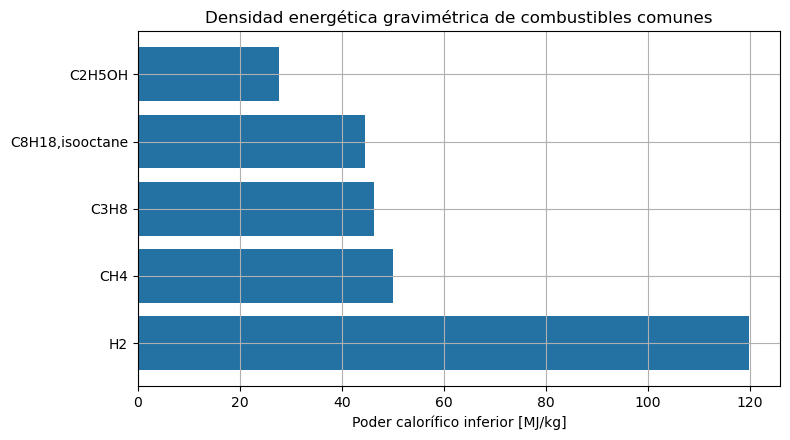

In [6]:
fig, ax = plt.subplots()
ax.barh(lhv_df.index, lhv_df["PCI [MJ/kg]"], color="#2471a3")
ax.set_xlabel("Poder calorífico inferior [MJ/kg]")
ax.set_title("Densidad energética gravimétrica de combustibles comunes")
fig.tight_layout()
plt.show()

## 4. Poder Calorífico Superior (PCS)

Si el agua producto se condensa a estado **líquido**, su calor latente se
recupera y la energía liberada es mayor — el **poder calorífico superior**. La
diferencia es la entalpía de vaporización del agua producida:

$$\text{PCS} = \text{PCI} + n_{\mathrm{H_2O}}\,\Delta_\mathrm{vap} H_{\mathrm{H_2O}},
\qquad \Delta_\mathrm{vap} H \approx 44{,}0\ \text{kJ/mol a 298 K}.$$

Obtenemos $\Delta_\mathrm{vap}H$ de la propia base de datos como
$H^\circ_{\mathrm{H_2O(g)}} - H^\circ_{\mathrm{H_2O(L)}}$ cuando el agua líquida
está dentro del rango, usando 44,0 kJ/mol como alternativa.

In [ ]:
with ThermochemicalCalculator() as calc:
    gas = calc.calculate_properties(calc.get_available_species("H2O", exact_match=True)[0]["id"], 298.15)["h_relative"]
    liqp = calc.calculate_properties(calc.get_available_species("H2O(L)", exact_match=True)[0]["id"], 298.15)
    dvap = (gas - liqp["h_relative"]) / 1000.0
    source = "base de datos (H2O gas - H2O líquido)"
print(f"Entalpía de vaporización del agua utilizada: {dvap:.2f} kJ/mol  [{source}]")

rows = []
with ThermochemicalCalculator() as calc:
    for fuel, (nO2, nCO2, nH2O) in FUELS.items():
        lhv = -reaction_enthalpy(calc, {fuel: 1, "O2": nO2},
                                 {"CO2": nCO2, "H2O": nH2O}) / 1000.0
        hhv = lhv + nH2O * dvap
        rows.append({"combustible": fuel, "PCI [kJ/mol]": lhv, "PCS [kJ/mol]": hhv,
                     "PCS-PCI [kJ/mol]": hhv - lhv})
print(pd.DataFrame(rows).set_index("combustible").to_string())

Entalpía de vaporización del agua utilizada: 44.00 kJ/mol  [base de datos (H2O gas - H2O líquido)]
                 PCI [kJ/mol]  PCS [kJ/mol]  PCS-PCI [kJ/mol]
combustible                                                  
H2                    241.825       285.828            44.004
CH4                   802.557       890.565            88.008
C3H8                2,043.142     2,219.158           176.015
C2H5OH              1,277.541     1,409.552           132.012
C8H18,isooctane     5,100.475     5,496.509           396.035


## 5. Dependencia con la temperatura — ley de Kirchhoff

La entalpía de reacción varía con la temperatura porque productos y reactivos
tienen diferentes capacidades caloríficas:

$$\frac{d(\Delta H_\mathrm{rxn})}{dT} = \Delta C_p
  = \sum_{\text{prod}}\nu_j C_{p,j} - \sum_{\text{reac}}\nu_i C_{p,i}.$$

Trazamos $\Delta H_\mathrm{rxn}(T)$ para la combustión del metano y del
hidrógeno. Ambas son funciones débiles de $T$ ($\Delta C_p$ pequeño), razón por
la cual los calores de combustión a temperatura ambiente se usan frecuentemente
en un amplio rango.

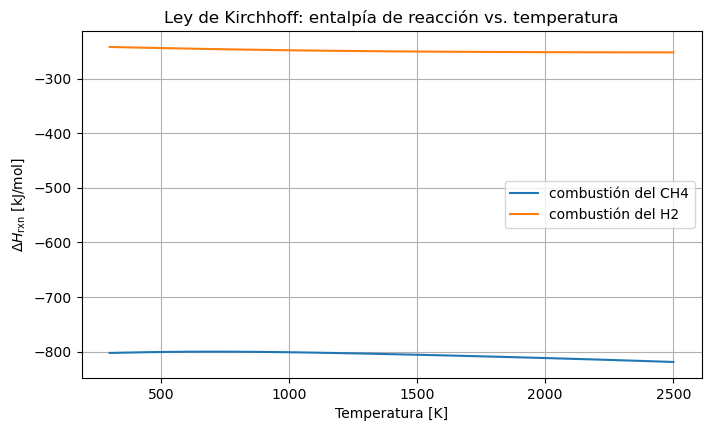

In [8]:
Tgrid = np.linspace(300, 2500, 60)
combustions = {
    "combustión del CH4": ({"CH4": 1, "O2": 2}, {"CO2": 1, "H2O": 2}),
    "combustión del H2":  ({"H2": 1, "O2": 0.5}, {"H2O": 1}),
}
fig, ax = plt.subplots()
with ThermochemicalCalculator() as calc:
    for label, (reac, prod) in combustions.items():
        dh = [reaction_enthalpy(calc, reac, prod, T) / 1000.0 for T in Tgrid]
        ax.plot(Tgrid, dh, label=label)
ax.set_xlabel("Temperatura [K]")
ax.set_ylabel(r"$\Delta H_\mathrm{rxn}$ [kJ/mol]")
ax.set_title("Ley de Kirchhoff: entalpía de reacción vs. temperatura")
ax.legend()
plt.show()

## 6. Ley de Hess

La entalpía de reacción es una función de estado: el camino en dos etapas
C(gr)→CO→CO₂ debe sumar lo mismo que el camino directo C(gr)→CO₂. `pyglenn`
respeta esto automáticamente porque toda entalpía está en la misma escala
estandarizada.

In [9]:
with ThermochemicalCalculator() as calc:
    step1 = reaction_enthalpy(calc, {"C(gr)": 1, "O2": 0.5}, {"CO": 1})
    step2 = reaction_enthalpy(calc, {"CO": 1, "O2": 0.5}, {"CO2": 1})
    direct = reaction_enthalpy(calc, {"C(gr)": 1, "O2": 1}, {"CO2": 1})

print(f"C(gr) + 1/2 O2 -> CO      : {step1/1000:8.2f} kJ/mol")
print(f"CO    + 1/2 O2 -> CO2     : {step2/1000:8.2f} kJ/mol")
print(f"suma de las dos etapas    : {(step1+step2)/1000:8.2f} kJ/mol")
print(f"directo C(gr) + O2 -> CO2 : {direct/1000:8.2f} kJ/mol")
assert np.isclose(step1 + step2, direct)
print("\nLa ley de Hess se cumple exactamente.")

C(gr) + 1/2 O2 -> CO      :  -110.53 kJ/mol
CO    + 1/2 O2 -> CO2     :  -282.97 kJ/mol
suma de las dos etapas    :  -393.51 kJ/mol
directo C(gr) + O2 -> CO2 :  -393.51 kJ/mol

La ley de Hess se cumple exactamente.


## Resumen

- La entalpía de reacción es una suma estequiométrica de entalpías estandarizadas
  en una línea.
- PCI (agua vapor) y PCS (agua líquida) se obtienen inmediatamente; los valores
  por kg clasifican combustibles para transporte.
- La ley de Kirchhoff da la dependencia con la temperatura; la ley de Hess es
  automática.

**A continuación:** el cuaderno 06 usa el mismo balance de entalpía para
calcular temperaturas de llama adiabática.